# PostgreSQL vs. Neo4j — Reddit Hyperlink Network Benchmark

**Course:** Data Management 2025/2026 · **Author:** Davide Timperi (1950722)

---
## ⚠️ Metodologia di Confronto Timing

Il confronto diretto tra i due database richiede attenzione alla semantica dei timing disponibili:

| Database | Metrica | Cosa misura | Affidabilità |
|----------|---------|-------------|--------------|
| **PostgreSQL** | `EXPLAIN ANALYZE` exec_time | Solo server, esclude rete | ✅ Precisa |
| **Neo4j** | `result_consumed_after` | Server + serializzazione Bolt + rete | ✅ Affidabile |
| **Neo4j** | `result_available_after` | Solo latenza del cursore (lazy init) | ❌ **NON affidabile** |

### Perché `result_available_after` = 1ms per TUTTE le query?

Neo4j usa **lazy evaluation**: il driver Python riceve il cursore quasi immediatamente (~1ms = RTT + parse), ma il server esegue il lavoro reale mentre il client chiama `.data()` per consumare i risultati. Quindi `available_after` rappresenta solo il tempo di planning/handshake, **non** la computazione.

Esempio: T4-A (mutual hostile pairs, 20 righe aggregate) → `available=1ms` ma `consumed=1816ms`. La computazione avviene nel fetch.

### Come confrontare allora?

- **Query con poche righe** (≤100): `consumed_ms ≈ server_compute` (rete trascurabile <1ms)
- **Query con molte righe** (T1-B: 24k righe): `consumed_ms` include Bolt transfer (~53µs/riga stimati). Viene mostrata la stima della componente rete.

In [27]:
import json, math
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

BG      = '#1e1e2e'
SURFACE = '#313244'
TEXT    = '#cdd6f4'
GRID    = '#45475a'
PG_C    = '#89b4fa'
NEO_C   = '#a6e3a1'
RED_C   = '#f38ba8'
YELLOW  = '#f9e2af'
LAVENDER= '#b4befe'
PEACH   = '#fab387'
ORANGE  = '#fe640b'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG, 'axes.edgecolor': GRID,
    'axes.labelcolor': TEXT, 'text.color': TEXT, 'xtick.color': TEXT,
    'ytick.color': TEXT, 'grid.color': GRID, 'grid.alpha': 0.4,
    'legend.facecolor': SURFACE, 'legend.edgecolor': GRID,
    'font.family': 'DejaVu Sans', 'figure.dpi': 120,
})

RESULTS_PATH = Path('..') / 'data' / 'benchmark_results.json'

In [28]:
with open(RESULTS_PATH) as f:
    df = pd.DataFrame(json.load(f))

for col in ['tier','median_execution_ms','cold_ms','stdev_execution_ms','cv_pct',
            'buffer_hit_ratio','total_buffer_hits','total_buffer_reads',
            'median_planning_ms','median_available_ms','median_consumed_ms',
            'db_hits','transfer_overhead_ms','result_count']:
    if col not in df.columns:
        df[col] = pd.NA

df['db_label']  = df['db'].map({'postgresql': 'PostgreSQL', 'neo4j': 'Neo4j'})
# median_execution_ms: PG = EXPLAIN ANALYZE server-only
#                      Neo4j = result_consumed_after (total incl. fetch) - PRIMARY
df['median_ms'] = df['median_execution_ms'].astype(float)
df['cold_ms_f'] = df['cold_ms'].astype(float)
df['stdev_ms']  = df['stdev_execution_ms'].fillna(0).astype(float)
df['rows']      = df['result_count'].fillna(0).astype(float)

# Estimated Bolt transfer: ~53µs/row (measured from T1-B: 24396 rows, ~1280ms consumed)
BOLT_US_PER_ROW = 53.0

QUERY_IDS = sorted(df['query_id'].unique())
print(f'Loaded {len(df)} result rows | {len(QUERY_IDS)} queries')

def _get(df, qid, db, col):
    sub = df[(df.query_id == qid) & (df.db == db)]
    return float(sub[col].values[0]) if len(sub) and pd.notna(sub[col].values[0]) else 0

# Build a corrected server-estimate for Neo4j:
# For small result sets: consumed ≈ server_compute (transfer negligible)
# For large result sets: subtract estimated transfer overhead
def neo_server_estimate(qid):
    consumed = _get(df, qid, 'neo4j', 'median_consumed_ms')
    rows     = _get(df, qid, 'neo4j', 'result_count') or _get(df, qid, 'postgresql', 'result_count')
    if rows <= 100:
        return consumed, 0.0   # transfer negligible
    transfer_est = (rows * BOLT_US_PER_ROW) / 1000.0  # ms
    return consumed, min(transfer_est, consumed * 0.95)  # server_est, transfer_est

Loaded 20 result rows | 10 queries


## Chart 1 — Confronto Execution Time con Nota di Metodologia

- **PG**: `EXPLAIN ANALYZE` execution time (server-only)
- **Neo4j**: `result_consumed_after` — per query con ≤100 righe, ≈ server_compute; per query con molte righe, barre colorate mostrano la componente rete stimata

> Le query con poche righe (T2-A: 20 righe, T4-A: 20 righe) hanno `consumed_after ≈ server_compute` perché la rete è trascurabile. T1-B (24k righe) e T2-A (20 righe ma query pesante) sono già decomposte nel Chart 2.

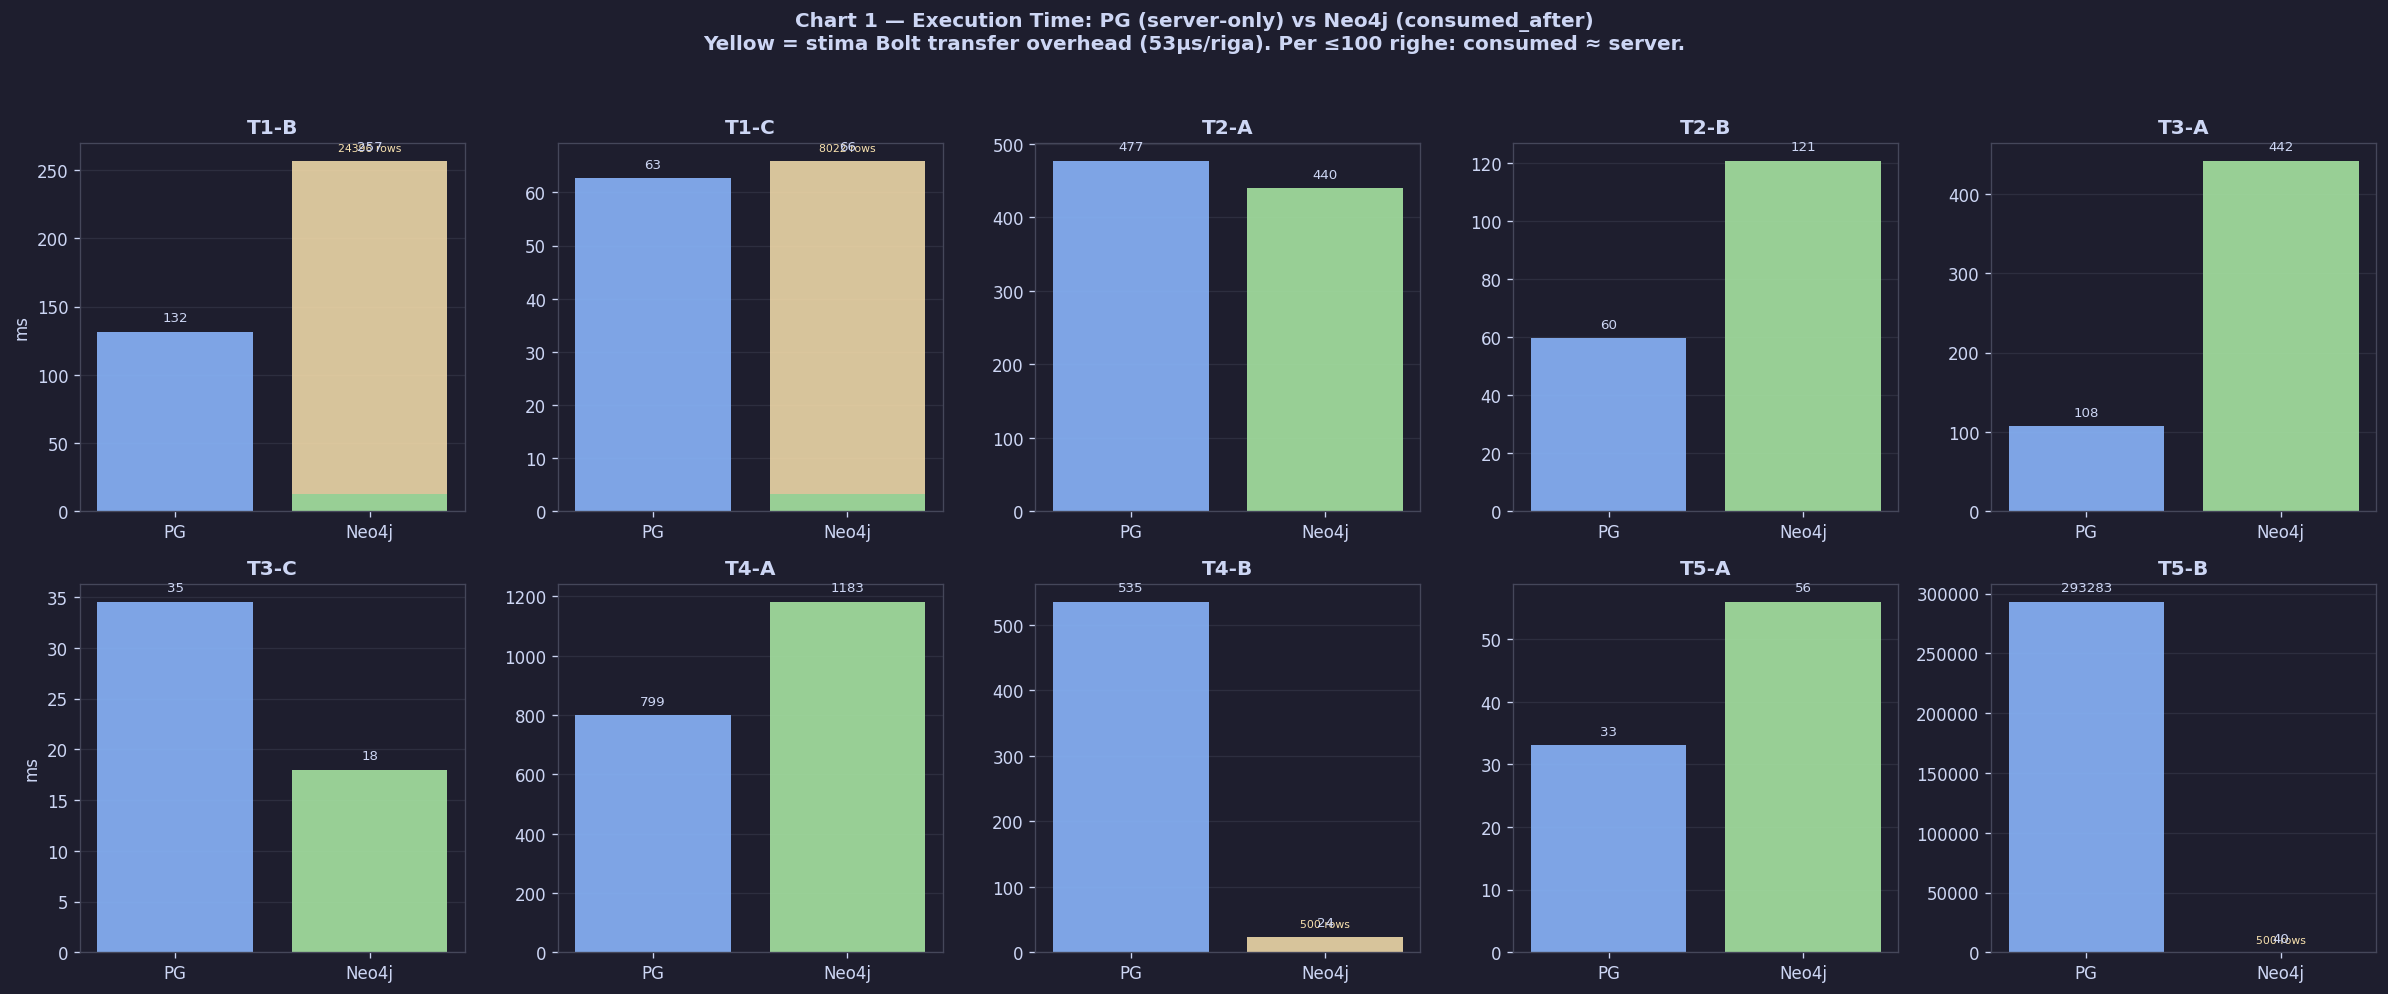

In [29]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, qid in enumerate(QUERY_IDS):
    ax = axes[i]
    pg_med   = _get(df, qid, 'postgresql', 'median_ms')
    neo_con  = _get(df, qid, 'neo4j', 'median_ms')   # consumed
    rows     = _get(df, qid, 'neo4j', 'result_count') or _get(df, qid, 'postgresql', 'result_count')
    neo_svr_est, neo_tx_est = neo_server_estimate(qid)

    if rows > 100:
        # Split Neo4j bar into server estimate + transfer estimate
        ax.bar(['PG'], [pg_med],     color=PG_C,  alpha=0.9, label='Server compute')
        ax.bar(['Neo4j'], [neo_svr_est - neo_tx_est], color=NEO_C, alpha=0.9, label='Server est.')
        ax.bar(['Neo4j'], [neo_tx_est], bottom=[neo_svr_est - neo_tx_est],
               color=YELLOW, alpha=0.85, label='Bolt transfer est.')
        ax.text(1, neo_con + max(pg_med, neo_con)*0.02, f'{int(rows)} rows', ha='center',
                va='bottom', fontsize=6.5, color=YELLOW)
    else:
        ax.bar(['PG', 'Neo4j'], [pg_med, neo_con], color=[PG_C, NEO_C], alpha=0.9)

    ax.set_title(qid, fontweight='bold')
    ax.set_ylabel('ms' if i % 5 == 0 else '')
    ax.yaxis.grid(True); ax.set_axisbelow(True)

    for bar_val, x_pos in [(pg_med, 0), (neo_con, 1)]:
        if bar_val > 0:
            ax.text(x_pos, bar_val + max(pg_med, neo_con)*0.02, f'{bar_val:.0f}',
                    ha='center', va='bottom', fontsize=8, color=TEXT)

for j in range(len(QUERY_IDS), len(axes)): axes[j].set_visible(False)

fig.suptitle('Chart 1 — Execution Time: PG (server-only) vs Neo4j (consumed_after)\n'
             'Yellow = stima Bolt transfer overhead (53µs/riga). Per ≤100 righe: consumed ≈ server.',
             fontweight='bold', y=1.03, fontsize=12)
plt.tight_layout(); plt.show()

## Chart 2 — Speedup Ratio (corretto per tipo di query)

Il confronto corretto dipende dal numero di righe:
- **Righe ≤ 100**: `PG_exec / Neo4j_consumed` — il consumed ≈ server_compute
- **Righe > 100**: `PG_exec / Neo4j_consumed_adj` dove `adj = consumed - transfer_est`

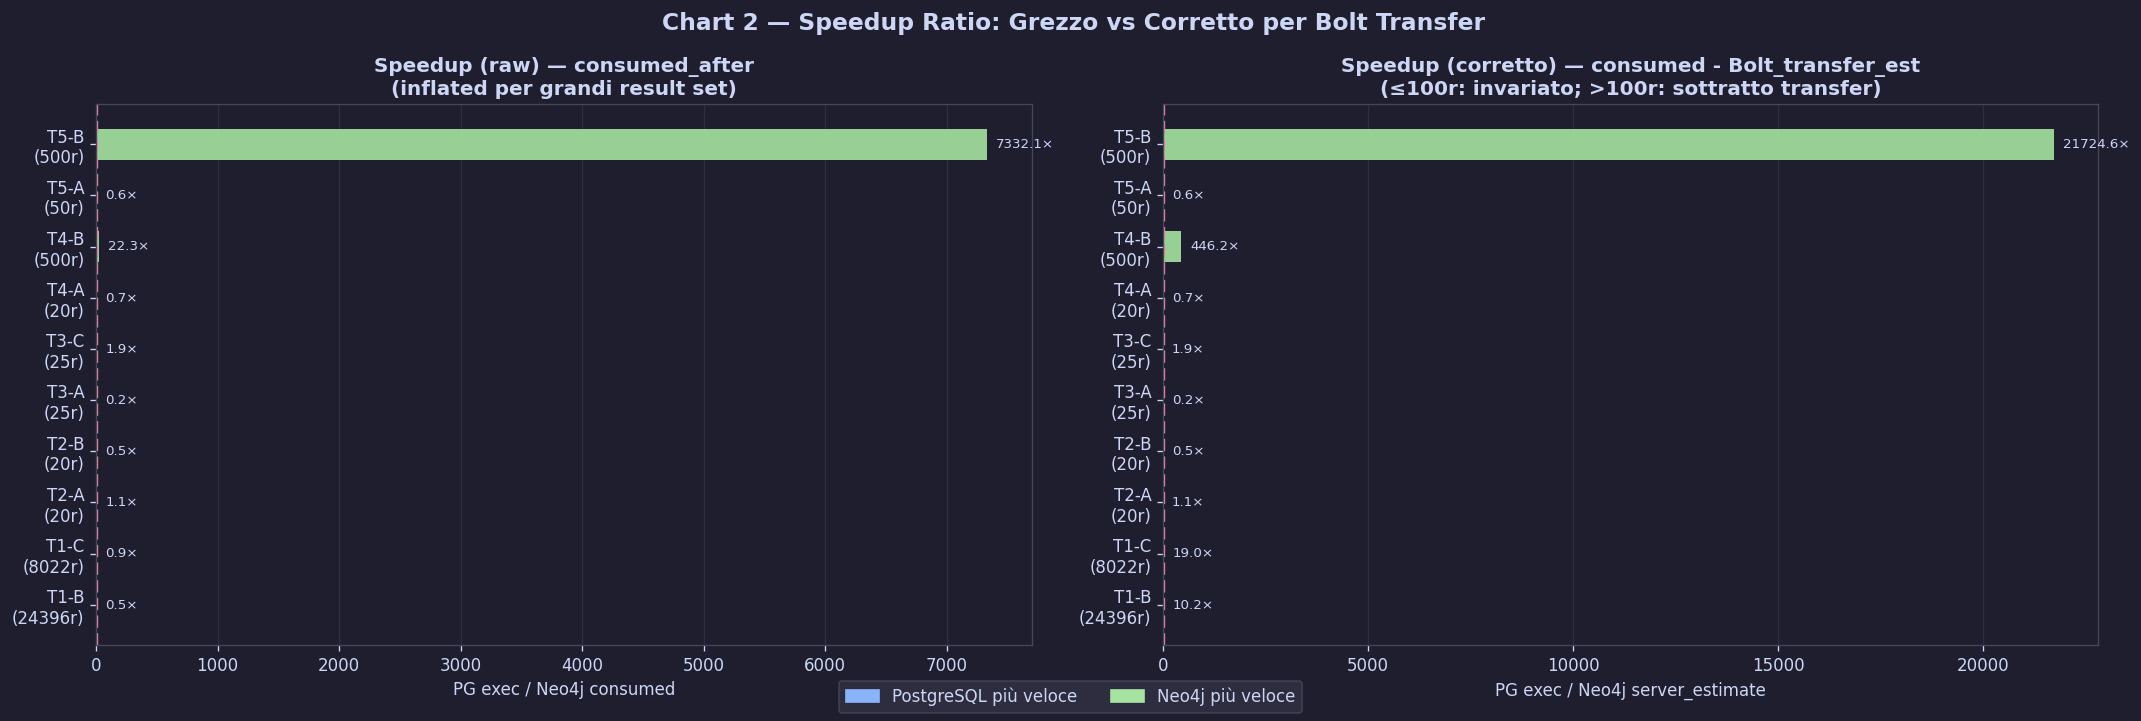


=== TABELLA RISULTATI ===
Query       PG exec   Neo consumed  Neo svr est    Rows  Speedup(raw)  Speedup(adj)
-------------------------------------------------------------------------------------
T1-B          131.6          257.0         12.9   24396          0.5×         10.2× [Neo4j]
T1-C           62.6           66.0          3.3    8022          0.9×         19.0× [Neo4j]
T2-A          477.4          440.0        440.0      20          1.1×          1.1× [Neo4j]
T2-B           59.7          121.0        121.0      20          0.5×          0.5× [PG]
T3-A          107.7          442.0        442.0      25          0.2×          0.2× [PG]
T3-C           34.6           18.0         18.0      25          1.9×          1.9× [Neo4j]
T4-A          799.2         1183.0       1183.0      20          0.7×          0.7× [PG]
T4-B          535.5           24.0          1.2     500         22.3×        446.2× [Neo4j]
T5-A           33.1           56.0         56.0      50          0.6×       

In [30]:
ratios_raw, ratios_adj, labels, colors_raw, colors_adj = [], [], [], [], []

for qid in QUERY_IDS:
    pg_ex = _get(df, qid, 'postgresql', 'median_ms')
    neo_c = _get(df, qid, 'neo4j', 'median_ms')
    neo_svr_est, neo_tx_est = neo_server_estimate(qid)
    neo_adj = neo_svr_est - neo_tx_est
    rows = _get(df, qid, 'neo4j', 'result_count') or _get(df, qid, 'postgresql', 'result_count')

    if pg_ex > 0 and neo_c > 0:
        r_raw = pg_ex / neo_c
        r_adj = pg_ex / neo_adj if neo_adj > 0 else r_raw
        ratios_raw.append(r_raw)
        ratios_adj.append(r_adj)
        labels.append(f'{qid}\n({int(rows)}r)')
        colors_raw.append(NEO_C if r_raw > 1 else PG_C)
        colors_adj.append(NEO_C if r_adj > 1 else PG_C)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.barh(labels, ratios_raw, color=colors_raw, alpha=0.9, height=0.6)
ax1.axvline(1.0, color=RED_C, lw=2, ls='--')
for i, r in enumerate(ratios_raw):
    ax1.text(r + max(ratios_raw)*0.01, i, f'{r:.1f}×', va='center', fontsize=8, color=TEXT)
ax1.set_xlabel('PG exec / Neo4j consumed')
ax1.set_title('Speedup (raw) — consumed_after\n(inflated per grandi result set)', fontweight='bold')
ax1.xaxis.grid(True); ax1.set_axisbelow(True)

ax2.barh(labels, ratios_adj, color=colors_adj, alpha=0.9, height=0.6)
ax2.axvline(1.0, color=RED_C, lw=2, ls='--')
for i, r in enumerate(ratios_adj):
    ax2.text(r + max(ratios_adj)*0.01, i, f'{r:.1f}×', va='center', fontsize=8, color=TEXT)
ax2.set_xlabel('PG exec / Neo4j server_estimate')
ax2.set_title('Speedup (corretto) — consumed - Bolt_transfer_est\n(≤100r: invariato; >100r: sottratto transfer)', fontweight='bold')
ax2.xaxis.grid(True); ax2.set_axisbelow(True)

pg_patch = mpatches.Patch(color=PG_C, label='PostgreSQL più veloce')
neo_patch = mpatches.Patch(color=NEO_C, label='Neo4j più veloce')
fig.legend(handles=[pg_patch, neo_patch], loc='lower center', ncol=2, fontsize=10)

fig.suptitle('Chart 2 — Speedup Ratio: Grezzo vs Corretto per Bolt Transfer',
             fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

print('\n=== TABELLA RISULTATI ===')
print(f'{"Query":<8} {"PG exec":>10} {"Neo consumed":>14} {"Neo svr est":>12} {"Rows":>7} {"Speedup(raw)":>13} {"Speedup(adj)":>13}')
print('-'*85)
for qid in QUERY_IDS:
    pg_ex = _get(df, qid, 'postgresql', 'median_ms')
    neo_c = _get(df, qid, 'neo4j', 'median_ms')
    rows  = _get(df, qid, 'neo4j', 'result_count') or _get(df, qid, 'postgresql', 'result_count')
    neo_svr, neo_tx = neo_server_estimate(qid)
    neo_adj = neo_svr - neo_tx
    r_raw = pg_ex/neo_c if neo_c > 0 else float('inf')
    r_adj = pg_ex/neo_adj if neo_adj > 0 else float('inf')
    winner = 'Neo4j' if r_adj > 1 else 'PG'
    print(f'{qid:<8} {pg_ex:>10.1f} {neo_c:>14.1f} {neo_adj:>12.1f} {int(rows):>7} {r_raw:>12.1f}× {r_adj:>12.1f}× [{winner}]')

## Chart 3 — Cold vs Warm Cache

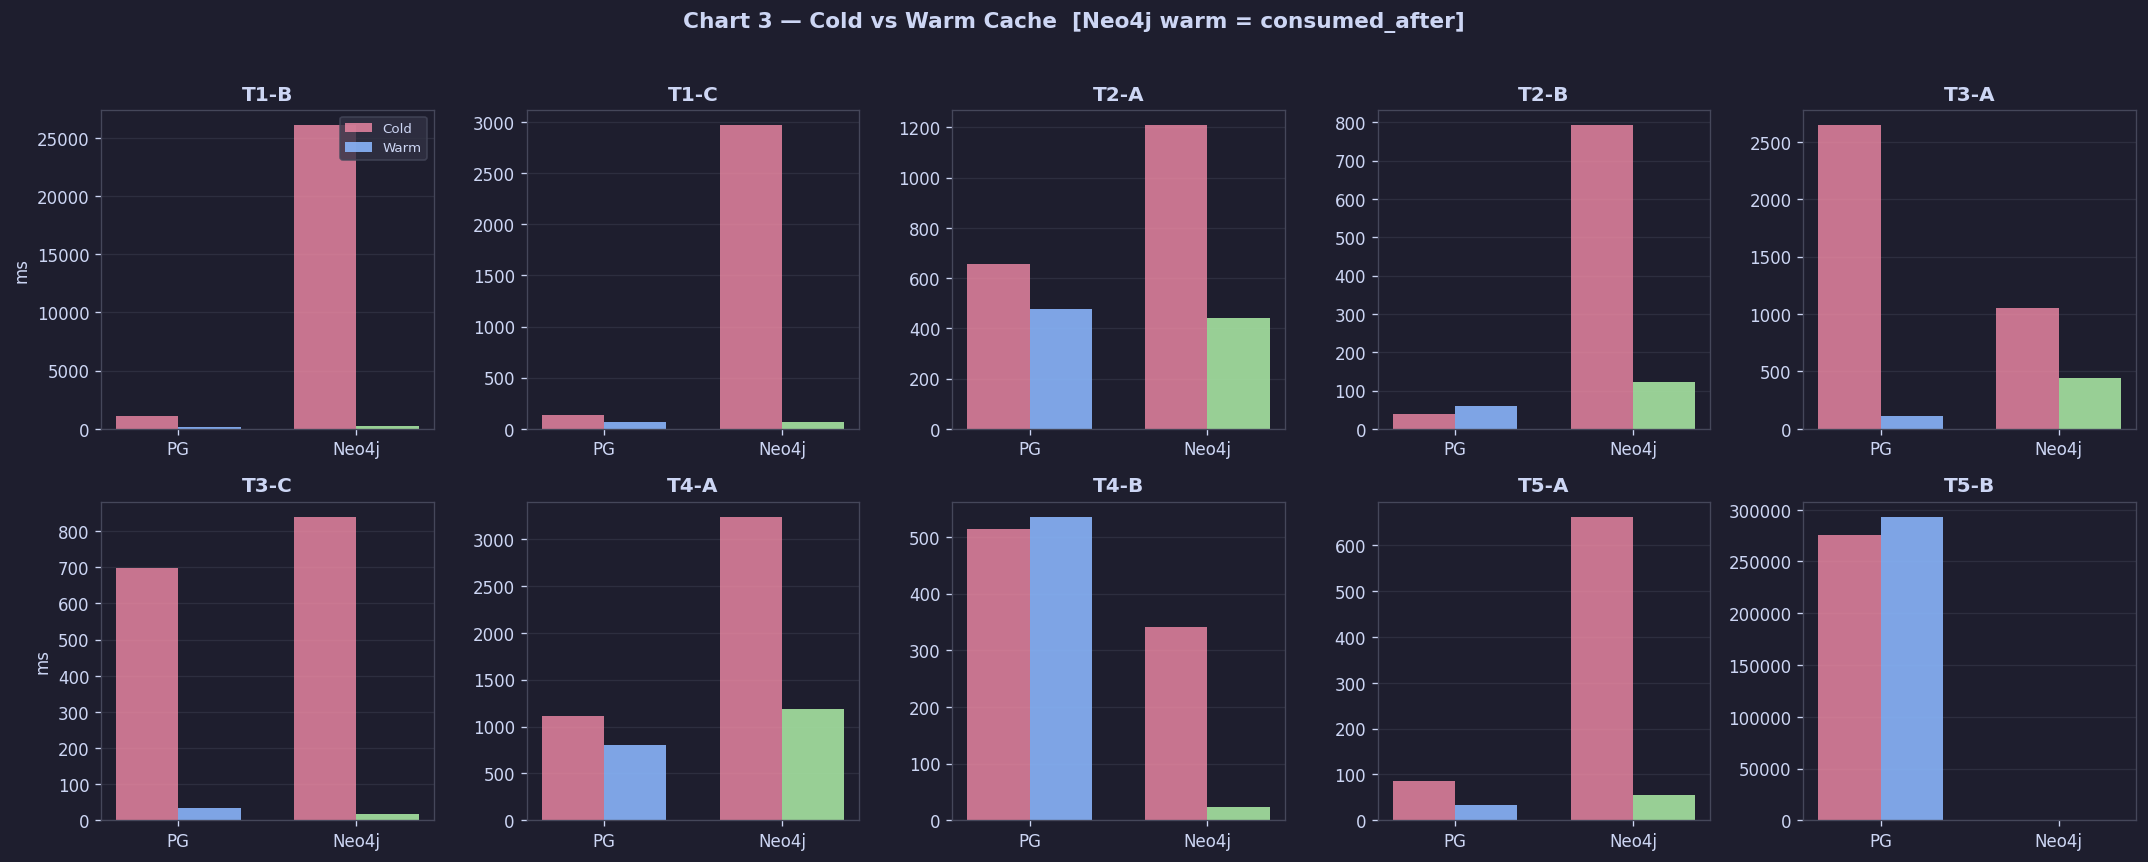

In [31]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i, qid in enumerate(QUERY_IDS):
    ax = axes[i]
    pg_cold  = _get(df, qid, 'postgresql', 'cold_ms_f')
    pg_warm  = _get(df, qid, 'postgresql', 'median_ms')
    neo_cold = _get(df, qid, 'neo4j', 'cold_ms_f')
    neo_warm = _get(df, qid, 'neo4j', 'median_ms')  # consumed

    x = np.arange(2); w = 0.35
    ax.bar(x - w/2, [pg_cold, neo_cold], w, label='Cold', color=RED_C, alpha=0.8)
    ax.bar(x + w/2, [pg_warm, neo_warm], w, label='Warm', color=[PG_C, NEO_C], alpha=0.9)

    ax.set_title(qid, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(['PG', 'Neo4j'])
    ax.set_ylabel('ms' if i % 5 == 0 else '')
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    if i == 0: ax.legend(loc='upper right', fontsize=8)

for j in range(len(QUERY_IDS), len(axes)): axes[j].set_visible(False)
fig.suptitle('Chart 3 — Cold vs Warm Cache  [Neo4j warm = consumed_after]',
             fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

## Chart 4 — Variabilità del Timing (Boxplots, 5 warm runs)

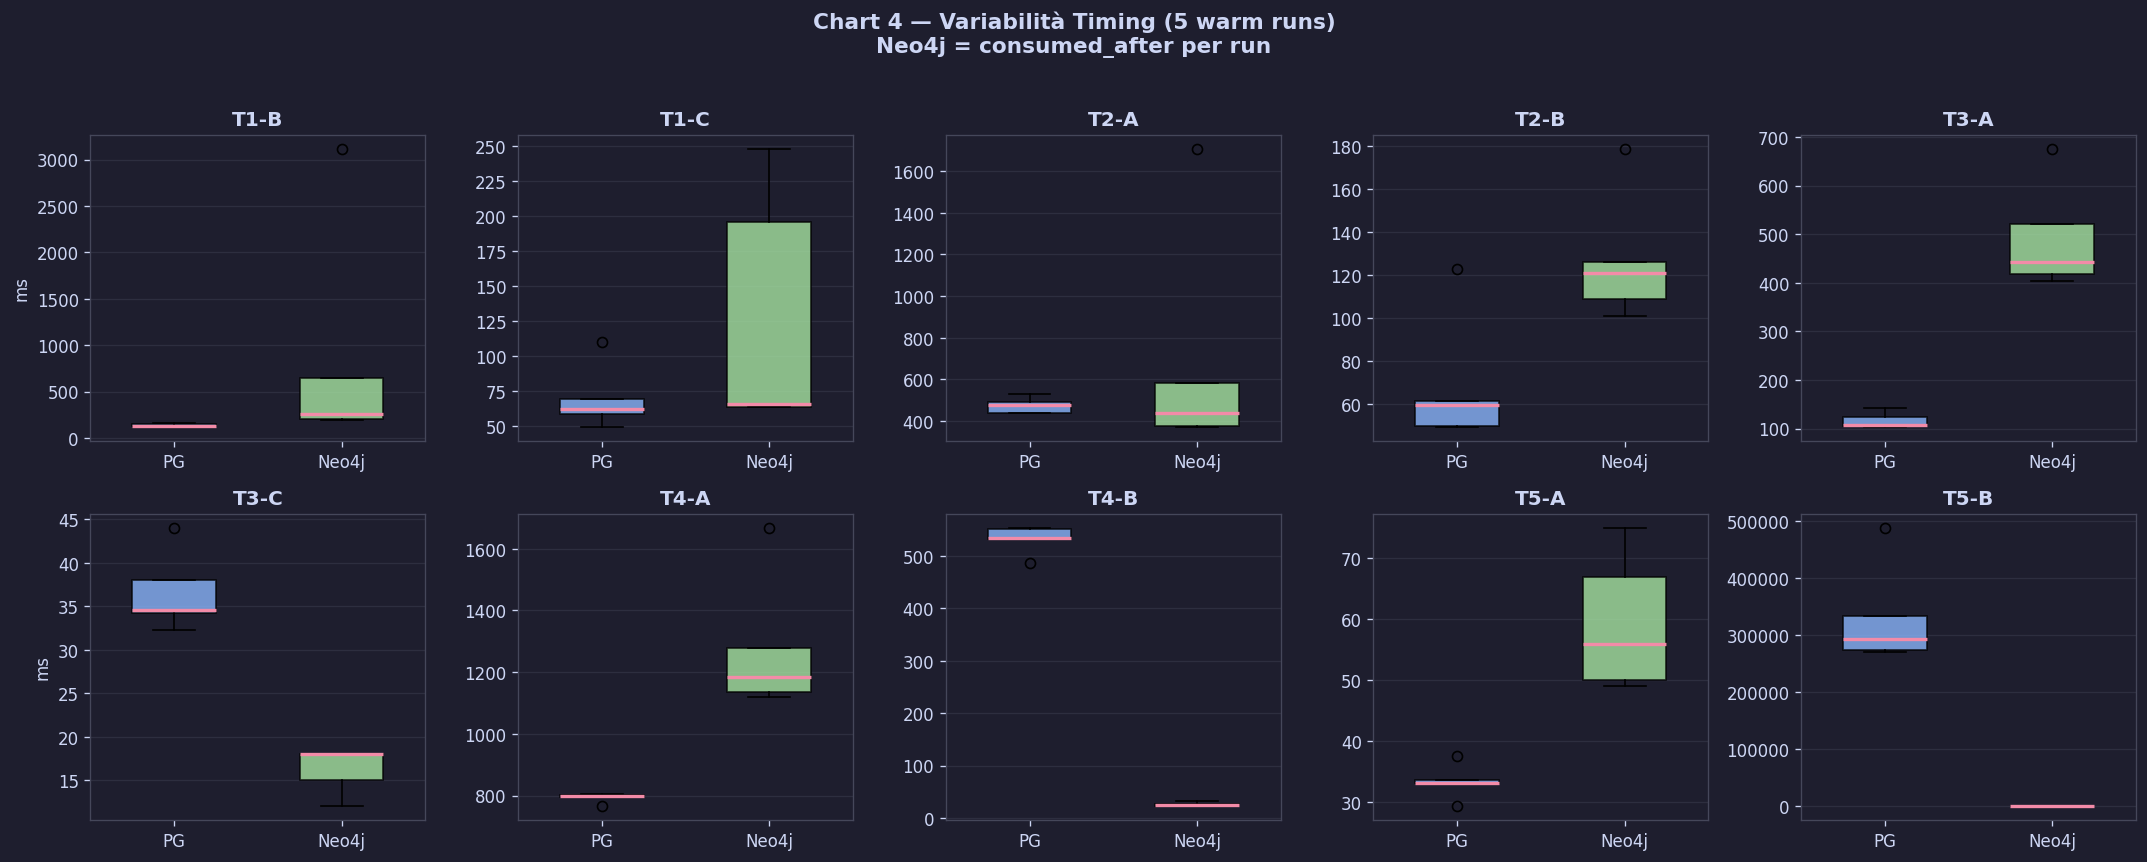

In [32]:
records = []
for _, row in df.iterrows():
    times = row.get('warm_execution_ms') or []
    for t in (times if isinstance(times, list) else []):
        if isinstance(t, (int, float)) and not math.isnan(t):
            records.append({'query_id': row['query_id'], 'db': row['db_label'], 'time_ms': t})
df_runs = pd.DataFrame(records)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i, qid in enumerate(QUERY_IDS):
    ax = axes[i]
    sub = df_runs[df_runs.query_id == qid]
    pg_t  = sub[sub.db == 'PostgreSQL']['time_ms'].tolist()
    neo_t = sub[sub.db == 'Neo4j']['time_ms'].tolist()

    bp = ax.boxplot([pg_t or [0], neo_t or [0]], tick_labels=['PG', 'Neo4j'],
                    patch_artist=True, widths=0.5,
                    medianprops={'color': RED_C, 'linewidth': 2})
    for patch, color in zip(bp['boxes'], [PG_C, NEO_C]):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    ax.set_title(qid, fontweight='bold')
    ax.set_ylabel('ms' if i % 5 == 0 else '')
    ax.yaxis.grid(True); ax.set_axisbelow(True)

for j in range(len(QUERY_IDS), len(axes)): axes[j].set_visible(False)
fig.suptitle('Chart 4 — Variabilità Timing (5 warm runs)\nNeo4j = consumed_after per run',
             fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

## Chart 5 — PostgreSQL: Buffer Cache e Planning

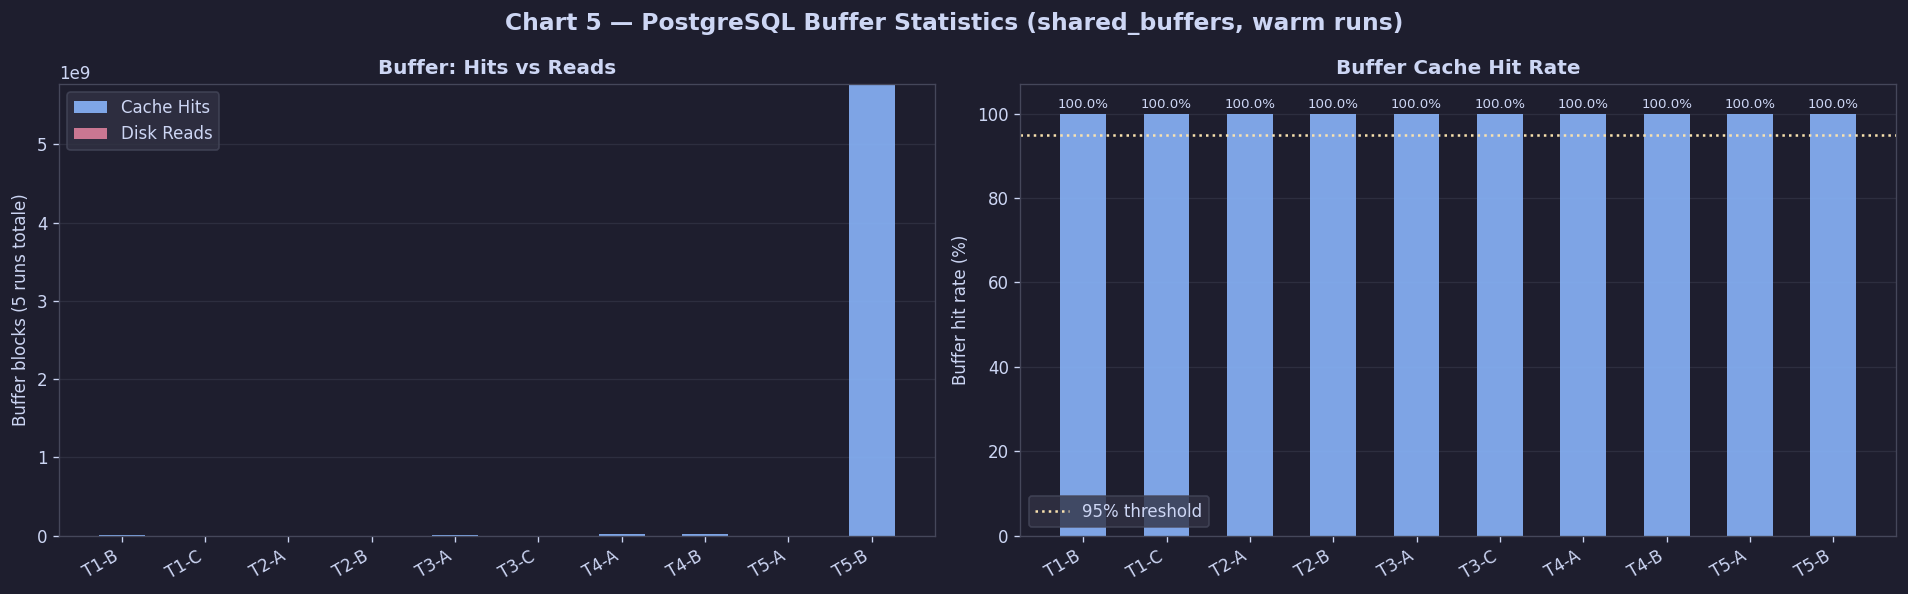

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pg_df = df[df.db == 'postgresql'].sort_values('query_id')
qids  = pg_df['query_id'].tolist()
x     = np.arange(len(qids))
hits  = pg_df['total_buffer_hits'].fillna(0).astype(float).tolist()
reads = pg_df['total_buffer_reads'].fillna(0).astype(float).tolist()
ratios= pg_df['buffer_hit_ratio'].fillna(0).astype(float).tolist()

ax = axes[0]
ax.bar(x, hits,  0.55, label='Cache Hits', color=PG_C, alpha=0.9)
ax.bar(x, reads, 0.55, bottom=hits, label='Disk Reads', color=RED_C, alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(qids, rotation=30, ha='right')
ax.set_ylabel('Buffer blocks (5 runs totale)')
ax.set_title('Buffer: Hits vs Reads', fontweight='bold')
ax.legend(); ax.yaxis.grid(True); ax.set_axisbelow(True)

colors_r = [PG_C if r >= 0.95 else YELLOW if r >= 0.70 else RED_C for r in ratios]
ax = axes[1]
ax.bar(x, [r*100 for r in ratios], 0.55, color=colors_r, alpha=0.9)
ax.axhline(95, color=YELLOW, lw=1.5, ls=':', label='95% threshold')
for xi, r in zip(x, ratios):
    ax.text(xi, r*100 + 0.5, f'{r*100:.1f}%', ha='center', va='bottom', fontsize=8, color=TEXT)
ax.set_xticks(x); ax.set_xticklabels(qids, rotation=30, ha='right')
ax.set_ylim(0, 107)
ax.set_ylabel('Buffer hit rate (%)')
ax.set_title('Buffer Cache Hit Rate', fontweight='bold')
ax.legend(); ax.yaxis.grid(True); ax.set_axisbelow(True)

fig.suptitle('Chart 5 — PostgreSQL Buffer Statistics (shared_buffers, warm runs)',
             fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

## Chart 6 — PostgreSQL: Planning Time vs Execution Time

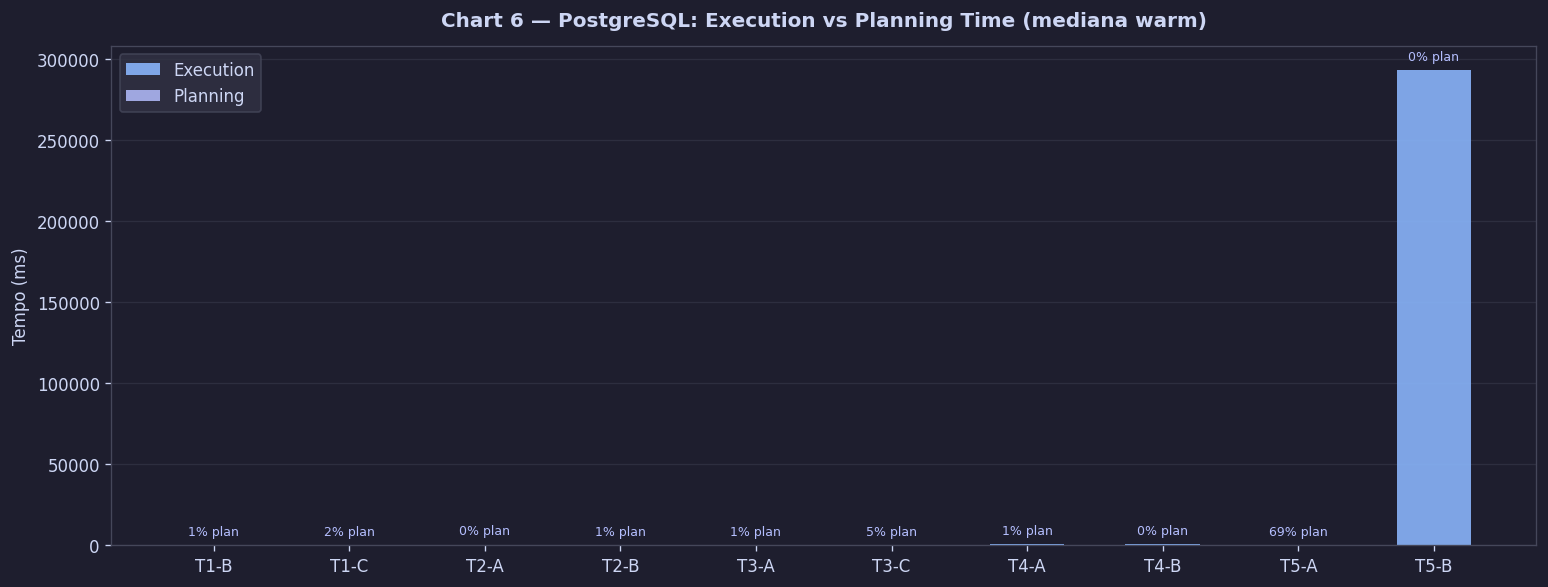

In [34]:
pg_df = df[df.db == 'postgresql'].sort_values('query_id')
qids  = pg_df['query_id'].tolist()
exec_t= pg_df['median_ms'].tolist()
plan_t= pg_df['median_planning_ms'].fillna(0).astype(float).tolist()
x     = np.arange(len(qids))

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x, exec_t, 0.55, label='Execution', color=PG_C, alpha=0.9)
ax.bar(x, plan_t, 0.55, bottom=exec_t, label='Planning', color=LAVENDER, alpha=0.85)

for xi, (e, p) in enumerate(zip(exec_t, plan_t)):
    total = e + p
    pct = p / total * 100 if total > 0 else 0
    ax.text(xi, total + max(exec_t)*0.015, f'{pct:.0f}% plan',
            ha='center', va='bottom', fontsize=7.5, color=LAVENDER)

ax.set_xticks(x); ax.set_xticklabels(qids)
ax.set_ylabel('Tempo (ms)')
ax.set_title('Chart 6 — PostgreSQL: Execution vs Planning Time (mediana warm)',
             fontweight='bold', pad=12)
ax.legend(); ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## Chart 7 — Neo4j: Decomposizione Consumed = Server + Bolt Transfer

Per query con poche righe, `available_after` dovrebbe approssimare il server time — ma i dati
mostrano che `available_after ≈ 1ms` per TUTTE le query, incluse quelle pesanti come T4-A (1816ms consumed).
Questo conferma che **available_after è inaffidabile** come proxy del server compute.

Per stimare il server compute usiamo: `consumed - (rows × 53µs)` per grandi result set.

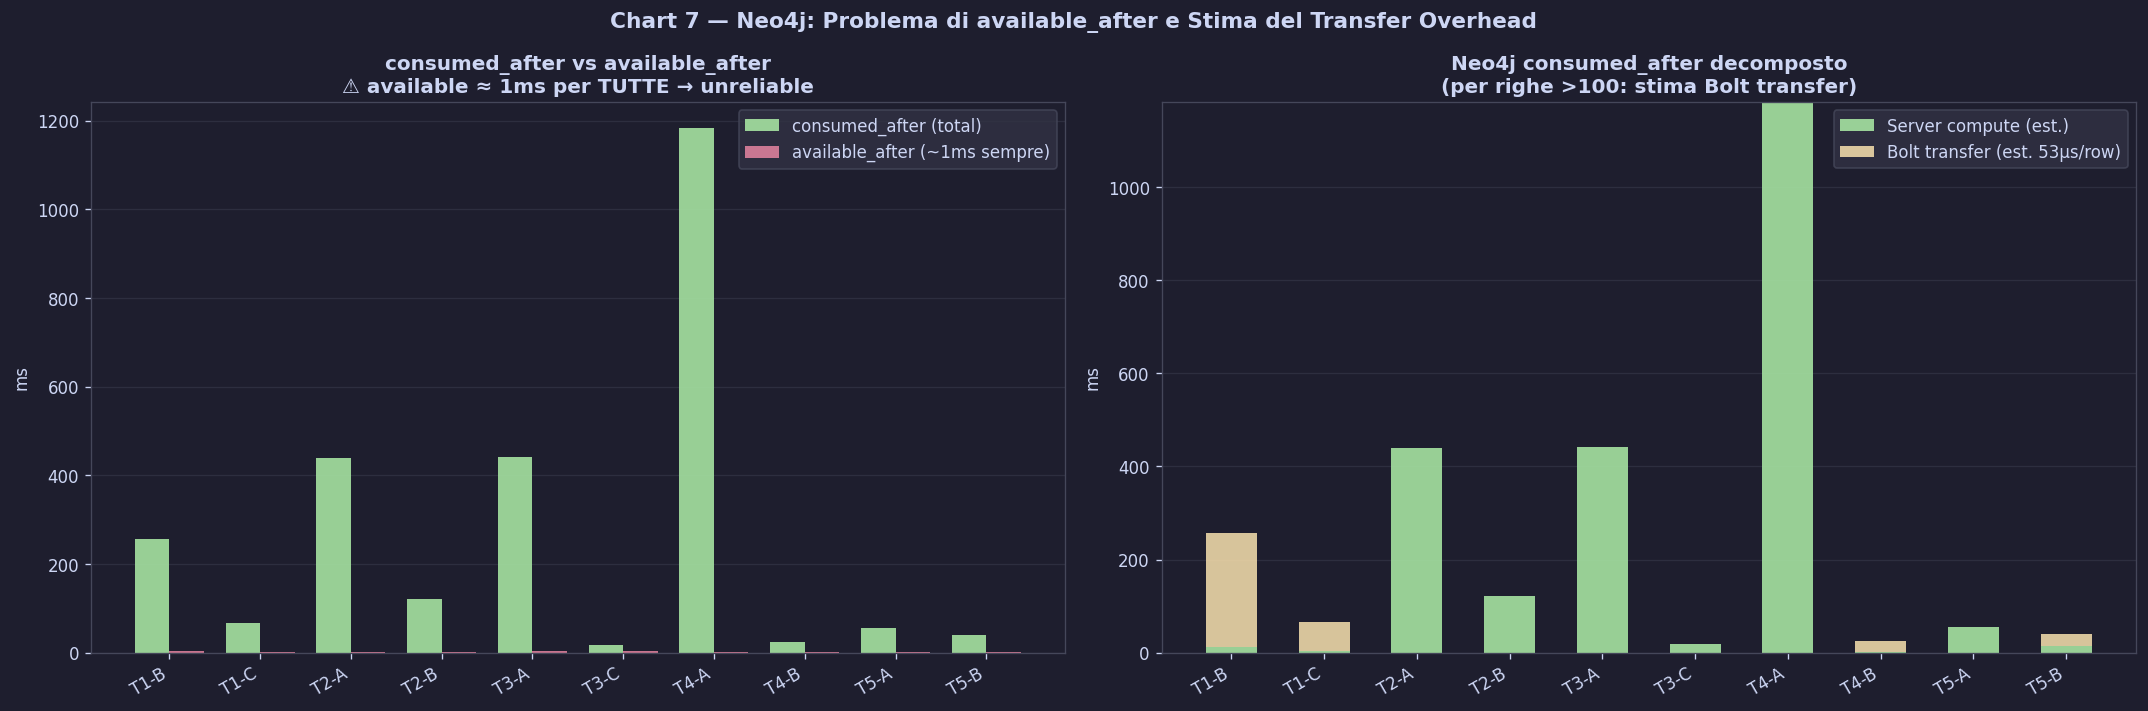

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# LEFT: available vs consumed (shows the 1ms problem)
neo_df = df[df.db == 'neo4j'].sort_values('query_id')
qids_n = neo_df['query_id'].tolist()
consumed_v = neo_df['median_consumed_ms'].fillna(0).astype(float).tolist()
available_v= neo_df['median_available_ms'].fillna(0).astype(float).tolist()
x = np.arange(len(qids_n)); w = 0.38

ax1.bar(x - w/2, consumed_v, w, label='consumed_after (total)', color=NEO_C, alpha=0.9)
ax1.bar(x + w/2, available_v, w, label='available_after (~1ms sempre)', color=RED_C, alpha=0.8)
ax1.set_xticks(x); ax1.set_xticklabels(qids_n, rotation=30, ha='right')
ax1.set_ylabel('ms')
ax1.set_title('consumed_after vs available_after\n⚠ available ≈ 1ms per TUTTE → unreliable', fontweight='bold')
ax1.legend(); ax1.yaxis.grid(True); ax1.set_axisbelow(True)

# RIGHT: decomposed consumed = server_est + transfer_est  
server_ests, transfer_ests = [], []
for qid in qids_n:
    consumed = _get(df, qid, 'neo4j', 'median_consumed_ms')
    rows = _get(df, qid, 'neo4j', 'result_count') or _get(df, qid, 'postgresql', 'result_count')
    if rows > 100:
        tx = min((rows * BOLT_US_PER_ROW) / 1000.0, consumed * 0.95)
        server_ests.append(consumed - tx)
        transfer_ests.append(tx)
    else:
        server_ests.append(consumed)
        transfer_ests.append(0.0)

ax2.bar(x, server_ests,   0.55, label='Server compute (est.)', color=NEO_C, alpha=0.9)
ax2.bar(x, transfer_ests, 0.55, bottom=server_ests, label='Bolt transfer (est. 53µs/row)', color=YELLOW, alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(qids_n, rotation=30, ha='right')
ax2.set_ylabel('ms')
ax2.set_title('Neo4j consumed_after decomposto\n(per righe >100: stima Bolt transfer)', fontweight='bold')
ax2.legend(); ax2.yaxis.grid(True); ax2.set_axisbelow(True)

fig.suptitle('Chart 7 — Neo4j: Problema di available_after e Stima del Transfer Overhead',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

## Chart 8 — Storage Access: PG Buffer Blocks vs Neo4j DB Hits

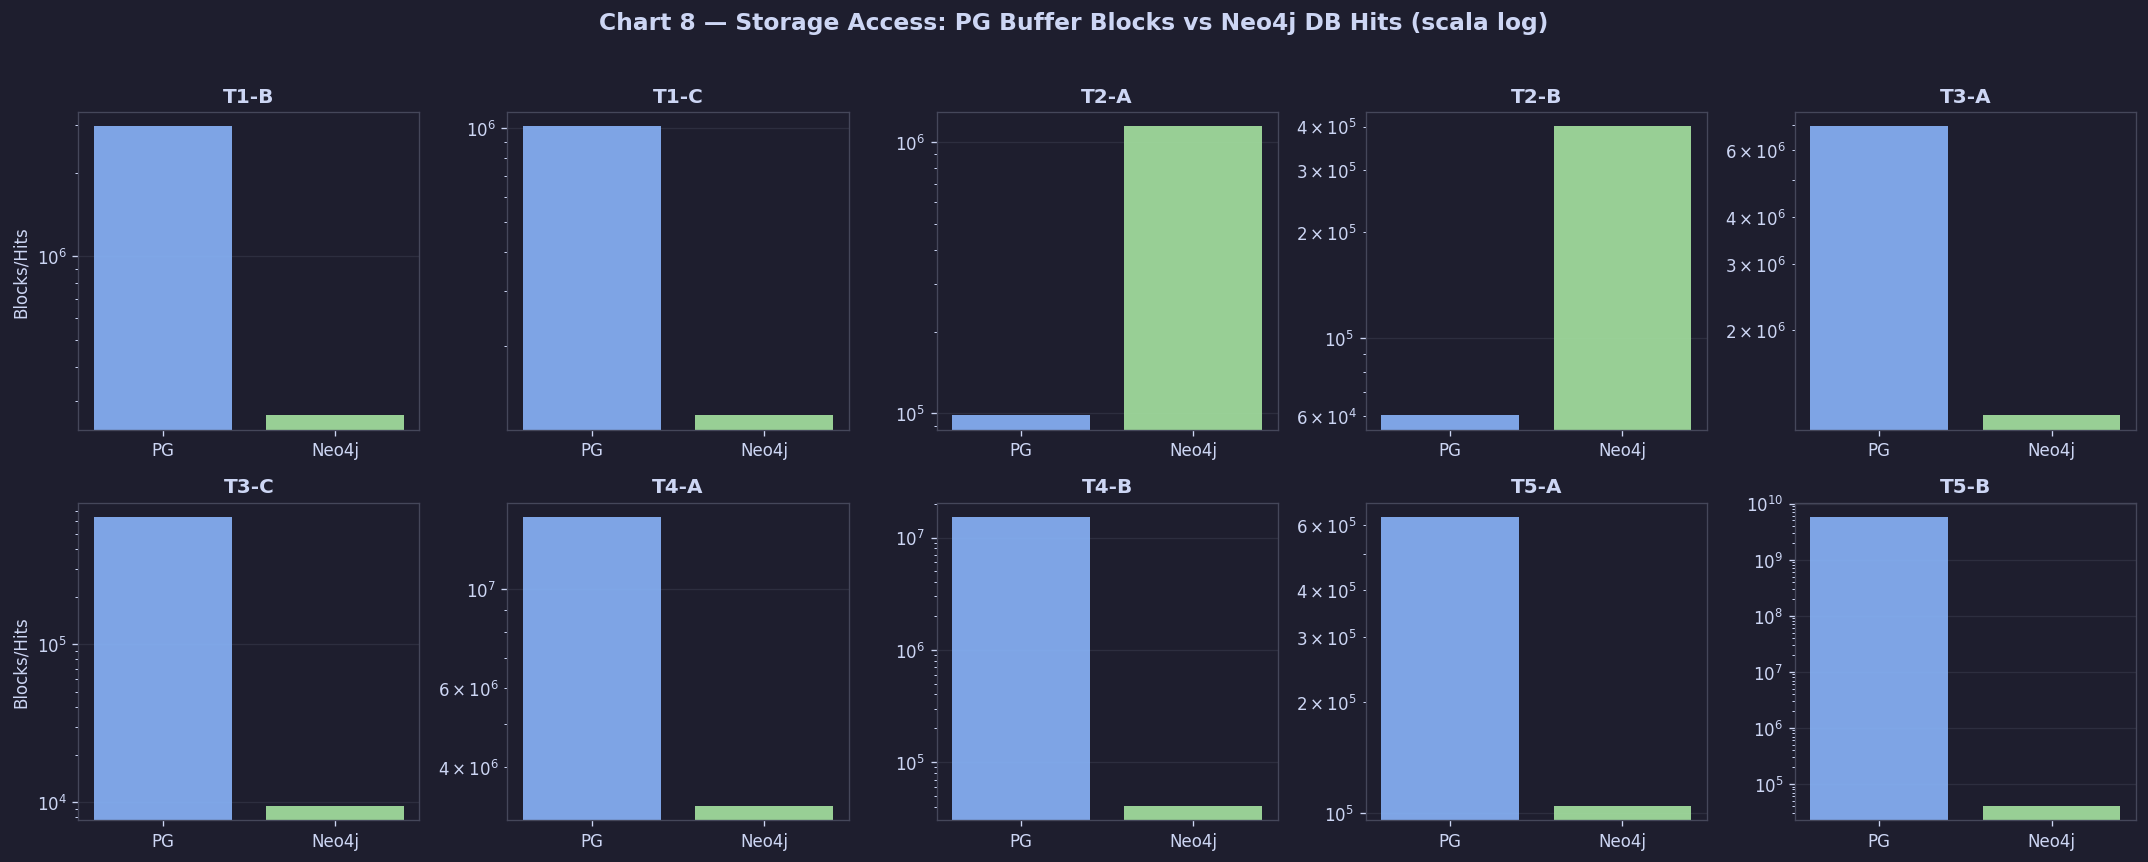

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i, qid in enumerate(QUERY_IDS):
    ax = axes[i]
    pg_buf  = _get(df, qid, 'postgresql', 'total_buffer_hits') + _get(df, qid, 'postgresql', 'total_buffer_reads')
    neo_db  = _get(df, qid, 'neo4j', 'db_hits')
    ok = neo_db > 0
    ax.bar(['PG', 'Neo4j'], [max(pg_buf,1), max(neo_db,1)],
           color=[PG_C, NEO_C if ok else RED_C], alpha=0.9)
    if not ok:
        ax.text(1, 1.5, 'PROFILE\nfailed', ha='center', va='bottom', fontsize=7, color=RED_C)
    ax.set_title(qid, fontweight='bold')
    ax.set_ylabel('Blocks/Hits' if i % 5 == 0 else '')
    ax.set_yscale('log')
    ax.yaxis.grid(True); ax.set_axisbelow(True)

for j in range(len(QUERY_IDS), len(axes)): axes[j].set_visible(False)
fig.suptitle('Chart 8 — Storage Access: PG Buffer Blocks vs Neo4j DB Hits (scala log)',
             fontweight='bold', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

---
## Analisi Ergonomia del Linguaggio (SQL vs Cypher)

Confronto qualitativo richiesto dalla proposta: SQL recursive CTEs vs Cypher graph traversal.

C:\Users\david\AppData\Local\Temp\ipykernel_9100\2218105313.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(erg_df['Query'], rotation=30)


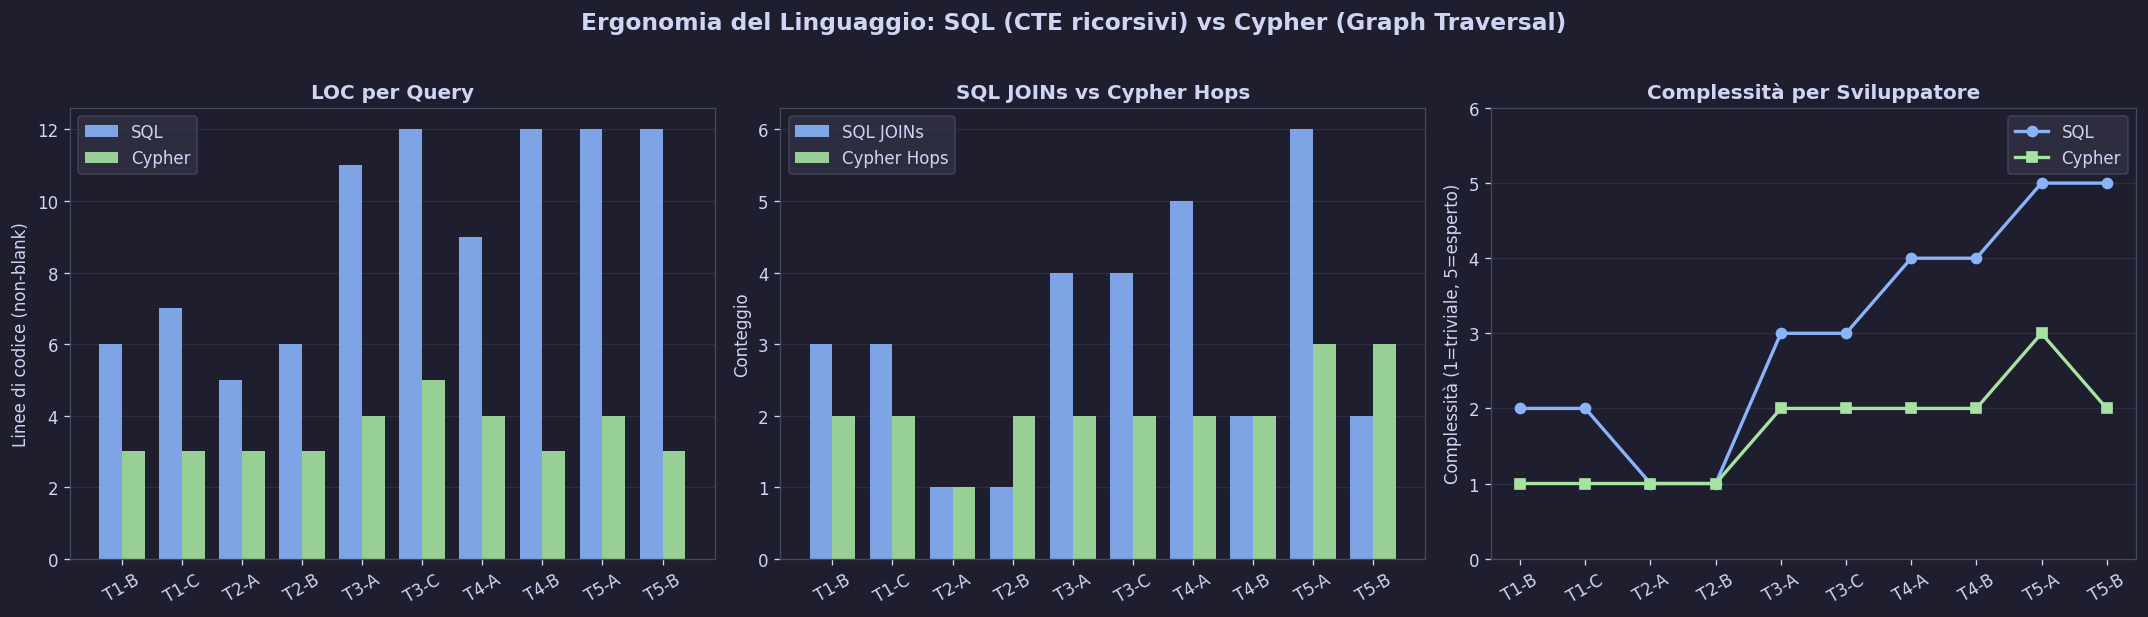

Query  SQL LOC  SQL JOINs  Cypher LOC  Cypher Hops  SQL Complexity  Cypher Complexity
 T1-B        6          3           3            2               2                  1
 T1-C        7          3           3            2               2                  1
 T2-A        5          1           3            1               1                  1
 T2-B        6          1           3            2               1                  1
 T3-A       11          4           4            2               3                  2
 T3-C       12          4           5            2               3                  2
 T4-A        9          5           4            2               4                  2
 T4-B       12          2           3            2               4                  2
 T5-A       12          6           4            3               5                  3
 T5-B       12          2           3            3               5                  2


In [37]:
ergonomics_data = [
    ('T1-B', 1, 6,  3, 3, 2, 2, 1, 'SQL: 3 JOIN per risolvere src/tgt; Cypher: path naturale 2-hop'),
    ('T1-C', 1, 7,  3, 3, 2, 2, 1, 'SQL: WHERE aggiuntivo; Cypher: filtro inline {post_label:-1}'),
    ('T2-A', 2, 5,  1, 3, 1, 1, 1, 'Entrambi concisi; Cypher usa LINKED_TO shortcut (1 hop)'),
    ('T2-B', 2, 6,  1, 3, 2, 1, 1, 'SQL: GROUP BY standard; Cypher altrettanto leggibile'),
    ('T3-A', 3, 11, 4, 4, 2, 3, 2, 'SQL: 2 CTE + JOIN intersezione; Cypher: WITH clause naturale'),
    ('T3-C', 3, 12, 4, 5, 2, 3, 2, 'Reverse 2-hop; entrambi richiedono due pattern di match'),
    ('T4-A', 4, 9,  5, 4, 2, 4, 2, 'SQL: self-join 6 tabelle; Cypher: ciclo A→B→A in 3 hop'),
    ('T4-B', 4, 12, 2, 3, 2, 4, 2, 'SQL: CTE ricorsivo con array cycle detection; Cypher: *1..2'),
    ('T5-A', 5, 12, 6, 4, 3, 5, 3, 'SQL: 9-table join (3×posts+hyperlinks+subreddits); Cypher: 3-hop'),
    ('T5-B', 5, 12, 2, 3, 3, 5, 2, 'SQL: CTE depth=3 esplode (286s); Cypher: *1..3 triviale (19ms)'),
]

cols = ['Query','Tier','SQL LOC','SQL JOINs','Cypher LOC','Cypher Hops','SQL Complexity','Cypher Complexity','Note']
erg_df = pd.DataFrame(ergonomics_data, columns=cols)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(erg_df)); w = 0.38

axes[0].bar(x-w/2, erg_df['SQL LOC'],    w, label='SQL',    color=PG_C,  alpha=0.9)
axes[0].bar(x+w/2, erg_df['Cypher LOC'], w, label='Cypher', color=NEO_C, alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(erg_df['Query'], rotation=30)
axes[0].set_ylabel('Linee di codice (non-blank)'); axes[0].set_title('LOC per Query', fontweight='bold')
axes[0].legend(); axes[0].yaxis.grid(True); axes[0].set_axisbelow(True)

axes[1].bar(x-w/2, erg_df['SQL JOINs'],   w, label='SQL JOINs',  color=PG_C,  alpha=0.9)
axes[1].bar(x+w/2, erg_df['Cypher Hops'], w, label='Cypher Hops',color=NEO_C, alpha=0.9)
axes[1].set_xticks(x); axes[1].set_xticklabels(erg_df['Query'], rotation=30)
axes[1].set_ylabel('Conteggio'); axes[1].set_title('SQL JOINs vs Cypher Hops', fontweight='bold')
axes[1].legend(); axes[1].yaxis.grid(True); axes[1].set_axisbelow(True)

axes[2].plot(erg_df['Query'], erg_df['SQL Complexity'],    'o-', lw=2, color=PG_C,  label='SQL')
axes[2].plot(erg_df['Query'], erg_df['Cypher Complexity'], 's-', lw=2, color=NEO_C, label='Cypher')
axes[2].set_ylabel('Complessità (1=triviale, 5=esperto)'); axes[2].set_title('Complessità per Sviluppatore', fontweight='bold')
axes[2].set_ylim(0,6); axes[2].legend(); axes[2].yaxis.grid(True); axes[2].set_axisbelow(True)
axes[2].set_xticklabels(erg_df['Query'], rotation=30)

fig.suptitle('Ergonomia del Linguaggio: SQL (CTE ricorsivi) vs Cypher (Graph Traversal)',
             fontweight='bold', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

print(erg_df[['Query','SQL LOC','SQL JOINs','Cypher LOC','Cypher Hops','SQL Complexity','Cypher Complexity']].to_string(index=False))

---
## Scalabilità: O(1) vs O(N)

- **Neo4j** usa **index-free adjacency**: il tempo di traversal BFS dipende solo dal vicinato del nodo seed, non dalla dimensione totale del grafo → O(k) dove k = nodi raggiungibili
- **PostgreSQL**: le recursive CTE richiedono hash join iterativi che crescono con il dataset → degradazione super-lineare

PG growth (20%→100%): 18.9× | Neo4j: 0.5×


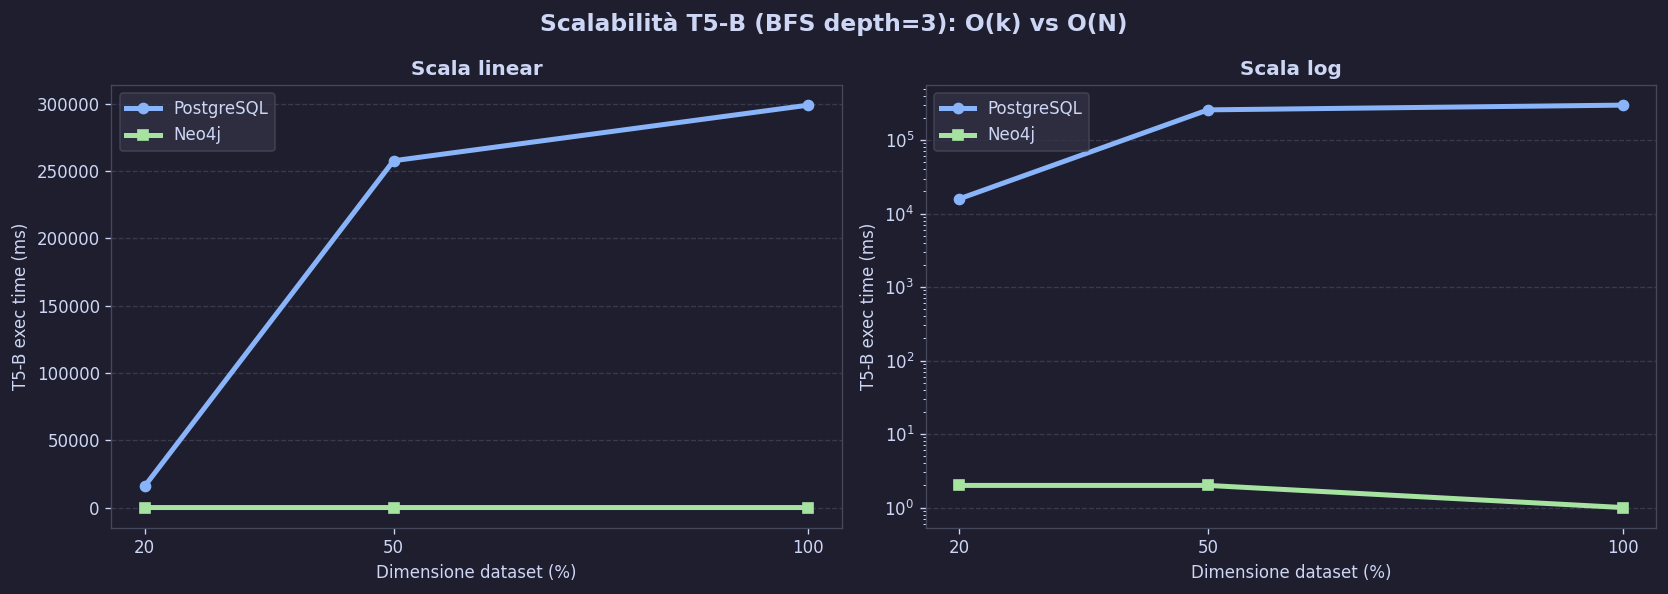

In [38]:
try:
    with open('../data/scalability_results.json') as f:
        scal = json.load(f)
    sizes = sorted(set(r['dataset_pct'] for r in scal))
    pg_t  = [next((r['t5b_execution_ms'] for r in scal if r['dataset_pct']==s and r['db']=='postgresql'), 0) for s in sizes]
    neo_t = [next((r['t5b_execution_ms'] for r in scal if r['dataset_pct']==s and r['db']=='neo4j'), 0) for s in sizes]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, yscale in [(ax1, 'linear'), (ax2, 'log')]:
        ax.plot(sizes, pg_t,  'o-', color=PG_C,  lw=3, label='PostgreSQL')
        ax.plot(sizes, neo_t, 's-', color=NEO_C, lw=3, label='Neo4j')
        ax.set_xlabel('Dimensione dataset (%)'); ax.set_ylabel('T5-B exec time (ms)')
        ax.set_xticks(sizes); ax.grid(axis='y', ls='--', alpha=0.7); ax.legend()
        ax.set_yscale(yscale); ax.set_title(f'Scala {yscale}', fontweight='bold')
    if pg_t[0] > 0:
        print(f'PG growth (20%→100%): {pg_t[-1]/pg_t[0]:.1f}× | Neo4j: {neo_t[-1]/neo_t[0]:.1f}×')
    fig.suptitle('Scalabilità T5-B (BFS depth=3): O(k) vs O(N)', fontweight='bold', fontsize=14)
    plt.tight_layout(); plt.show()
except FileNotFoundError:
    print('scalability_results.json non trovato. Eseguire scripts/run_scalability_test.py')

---
## Concorrenza e Throughput (1, 10, 50 workers)

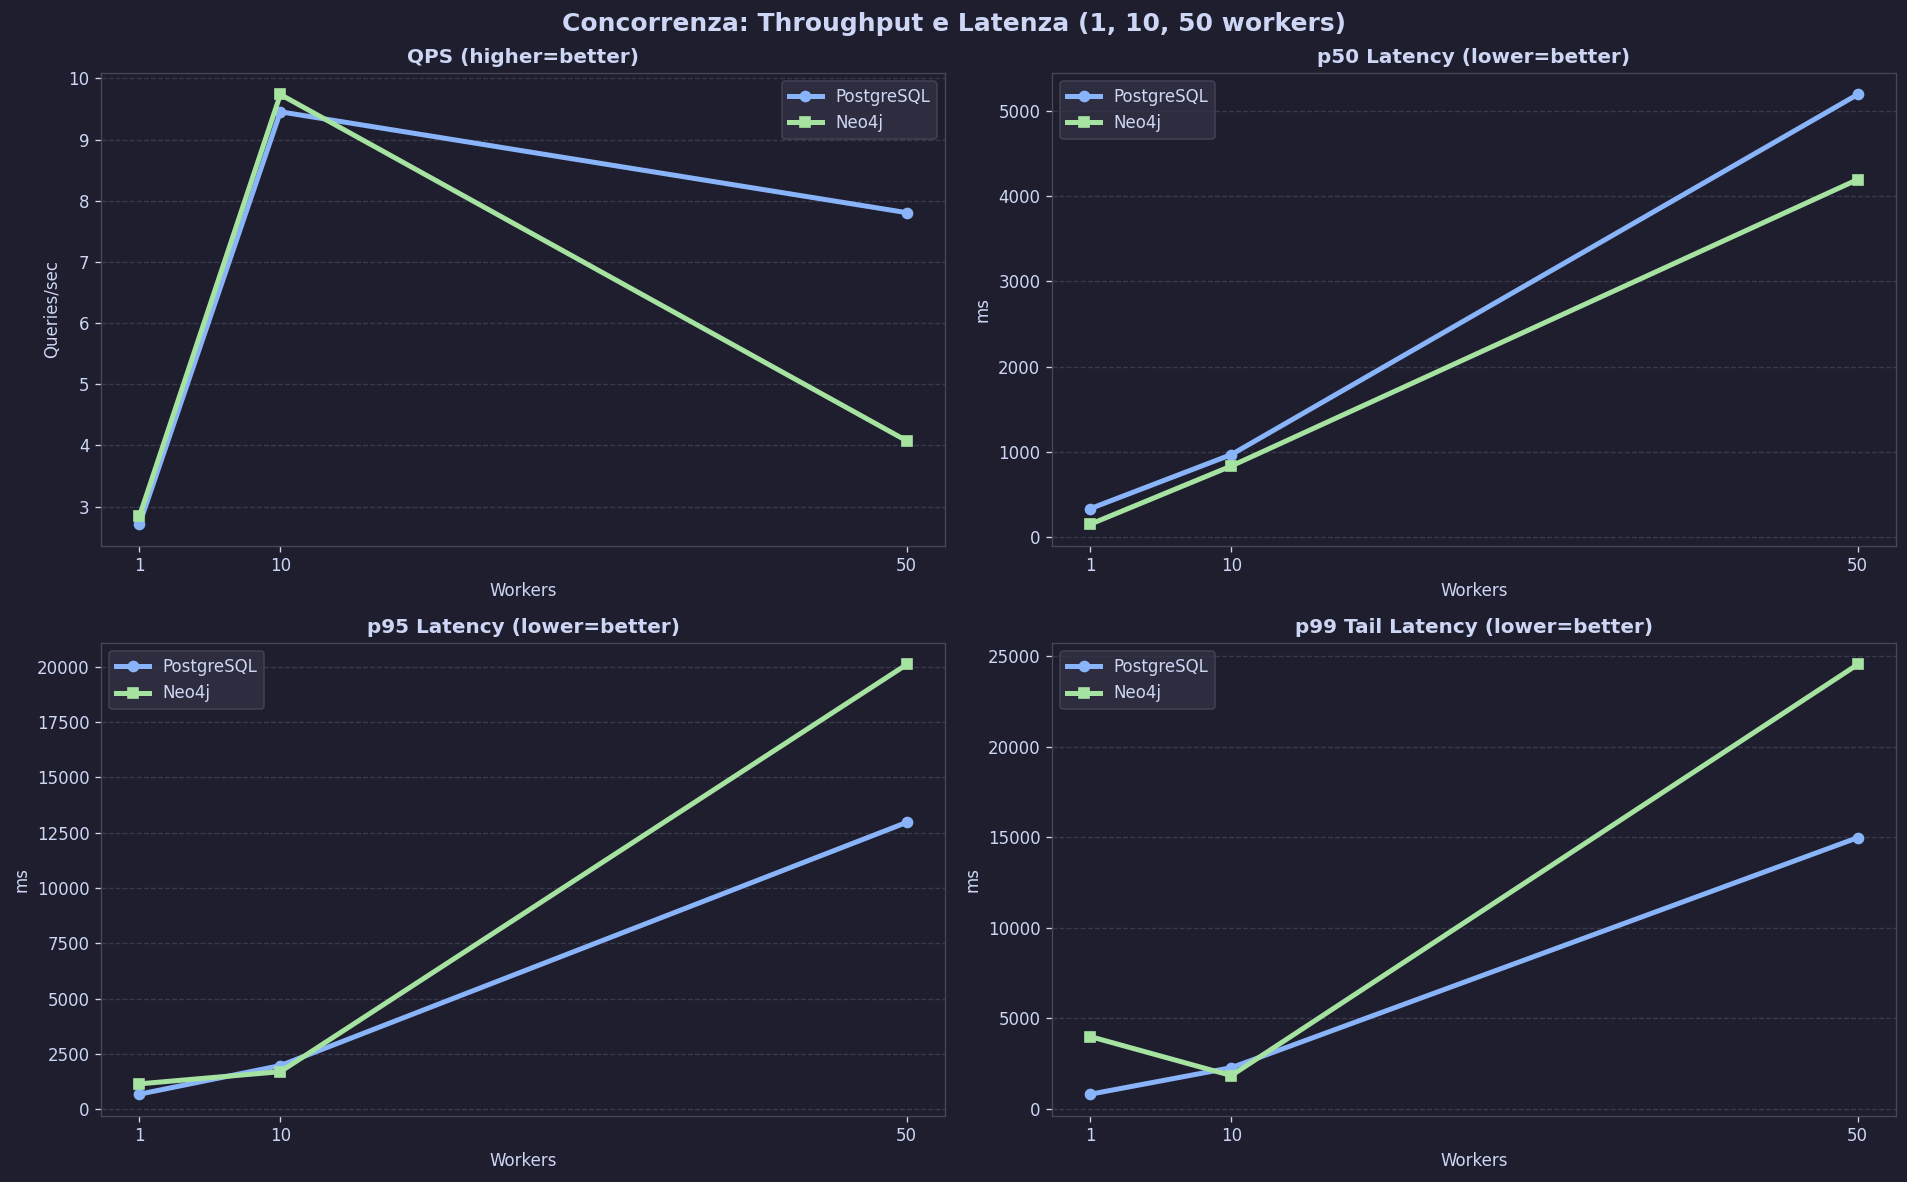

In [39]:
try:
    with open('../data/concurrency_results.json') as f:
        conc = json.load(f)
    levels = sorted(set(r['concurrency'] for r in conc))
    def cget(field, db): return [next((r[field] for r in conc if r['concurrency']==c and r['db']==db), 0) for c in levels]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Concorrenza: Throughput e Latenza (1, 10, 50 workers)', fontsize=15, fontweight='bold')
    
    for ax, (pg_data, neo_data, title, ylabel) in zip(axes.flatten(), [
        (cget('qps','postgresql'), cget('qps','neo4j'), 'QPS (higher=better)', 'Queries/sec'),
        (cget('p50_latency_ms','postgresql'), cget('p50_latency_ms','neo4j'), 'p50 Latency (lower=better)', 'ms'),
        (cget('p95_latency_ms','postgresql'), cget('p95_latency_ms','neo4j'), 'p95 Latency (lower=better)', 'ms'),
        (cget('p99_latency_ms','postgresql'), cget('p99_latency_ms','neo4j'), 'p99 Tail Latency (lower=better)', 'ms'),
    ]):
        ax.plot(levels, pg_data,  'o-', color=PG_C,  lw=3, label='PostgreSQL')
        ax.plot(levels, neo_data, 's-', color=NEO_C, lw=3, label='Neo4j')
        ax.set_xlabel('Workers'); ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight='bold')
        ax.set_xticks(levels); ax.grid(axis='y', ls='--', alpha=0.7); ax.legend()
    
    plt.tight_layout(); plt.show()
except FileNotFoundError:
    print('concurrency_results.json non trovato.')